In [1]:
import sys
import os

# Add project root to path
sys.path.append(os.path.abspath(".."))

In [2]:
from src.preprocess import load_data, split_data, build_preprocessor
from src.train import get_models, train_and_evaluate
from src.predict import predict_and_save

In [3]:
train, test, test_ids = load_data(
    "../data/training.csv",
    "../data/test.csv"
)


X_train, X_val, y_train, y_val = split_data(train)

preprocessor = build_preprocessor(X_train)



In [4]:
from src.train import get_models, train_and_evaluate

models = get_models(y_train)

best_model, results_df, pipelines = train_and_evaluate(
    models,
    preprocessor,
    X_train,
    X_val,
    y_train,
    y_val
)

results_df

logistic_regression -> CV AUC: 0.7895 (+/- 0.0046), Val AUC: 0.8021, PR AUC: 0.3234, KS: 0.4571
random_forest -> CV AUC: 0.8613 (+/- 0.0032), Val AUC: 0.8662, PR AUC: 0.3965, KS: 0.5795
gradient_boosting -> CV AUC: 0.8633 (+/- 0.0035), Val AUC: 0.8676, PR AUC: 0.4103, KS: 0.5813
xgboost -> CV AUC: 0.8647 (+/- 0.0036), Val AUC: 0.8689, PR AUC: 0.4071, KS: 0.5806


,model,cv_auc_mean,cv_auc_std,val_auc,pr_auc,ks
0,xgboost,0.864734,0.003554,0.868876,0.407110,0.580571
1,gradient_boosting,0.863308,0.003507,0.867571,0.410337,0.581254
2,random_forest,0.861349,0.003158,0.866165,0.396546,0.579520
3,logistic_regression,0.789489,0.004642,0.802137,0.323428,0.457082


XGBoost achieved the highest ROC-AUC and KS score and was selected as the final model candidate.

In [ ]:
#Lets us do some hyperparameter tuning next

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        eval_metric="logloss",
        random_state=42
    ))
])

param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [3, 4],
    "model__learning_rate": [0.03, 0.05],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

tuned_model = grid.best_estimator_

print("Best Params:", grid.best_params_)
print("Best CV AUC:", grid.best_score_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best Params: {'model__colsample_bytree': 0.8, 'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 300, 'model__subsample': 0.8}
Best CV AUC: 0.8642540202304337


In [9]:
from sklearn.metrics import roc_auc_score
from src.train import compute_ks
probs = tuned_model.predict_proba(X_val)[:, 1]

print("AUC:", roc_auc_score(y_val, probs))
print("KS:", compute_ks(y_val, probs))

AUC: 0.8690007077323657
KS: 0.5826153494634552


In [12]:
#Set final model
best_model = tuned_model

In [25]:
import numpy as np
import pandas as pd

# Compute mean absolute SHAP values
shap_importance = np.abs(shap_values).mean(axis=0)

# Create DataFrame
feature_importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance_score": shap_importance
}).sort_values(by="importance_score", ascending=False)

# Top 10 features
print(feature_importance_df.head(10))

                                feature  importance_score
0  RevolvingUtilizationOfUnsecuredLines          0.768382
2  NumberOfTime30-59DaysPastDueNotWorse          0.353783
6               NumberOfTimes90DaysLate          0.302505
1                                   age          0.208141
8  NumberOfTime60-89DaysPastDueNotWorse          0.153030
5       NumberOfOpenCreditLinesAndLoans          0.123248
3                             DebtRatio          0.095187
4                         MonthlyIncome          0.090779
7          NumberRealEstateLoansOrLines          0.090755
9                    NumberOfDependents          0.023912


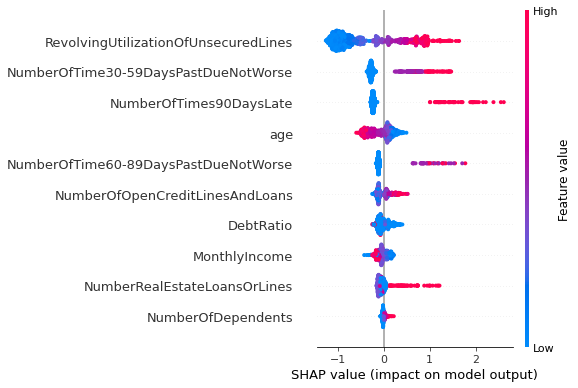

In [18]:
## SHAP steps ##
import shap

# Extract preprocessing and model from final pipeline
preprocessor = best_model.named_steps["preprocessor"]
model = best_model.named_steps["model"]

# Transform validation data
X_val_transformed = preprocessor.transform(X_val)
feature_names = list(X_val.columns)

# Use a smaller sample for faster SHAP computation
X_sample = X_val_transformed[:1000]

# Create SHAP explainer for tree-based model
explainer = shap.TreeExplainer(model)

# Compute SHAP values on the same sample used for plotting
shap_values = explainer.shap_values(X_sample)

# Global SHAP summary plot
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names
)

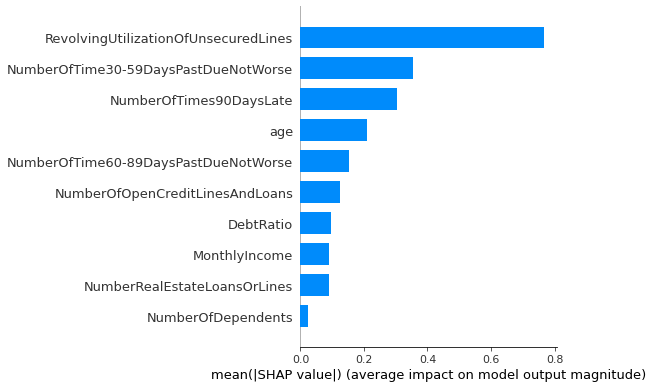

In [19]:
shap.summary_plot(
    shap_values,
    X_val_transformed,
    feature_names=feature_names,
    plot_type="bar"
)

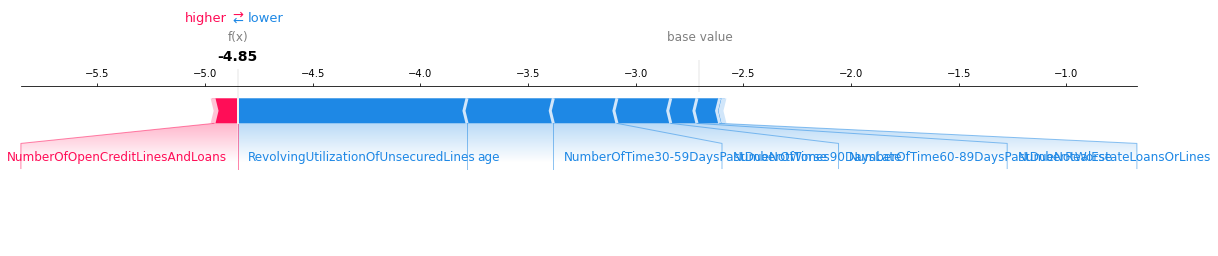

In [20]:
shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    feature_names=feature_names,
    matplotlib=True
)

Selected defaulter index in SHAP sample: 773
Actual value: 1
Predicted probability: 0.90438473


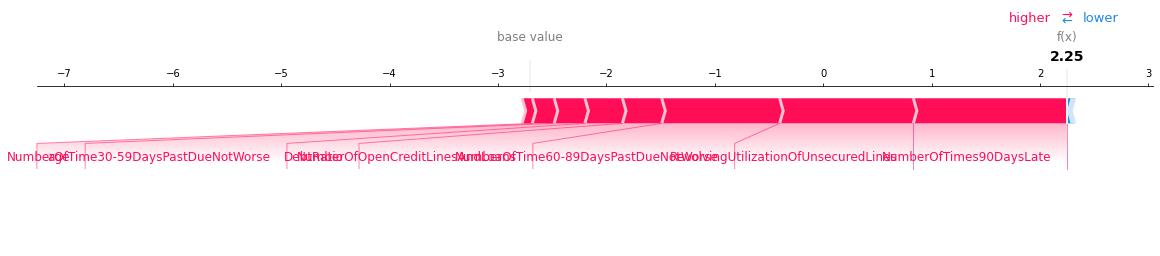

In [24]:
import numpy as np
import shap

# Predicted probabilities on validation set
y_val_proba = best_model.predict_proba(X_val)[:, 1]

# Restrict to same 1000 rows used for SHAP
y_val_sample = y_val.iloc[:1000].reset_index(drop=True)
y_val_proba_sample = y_val_proba[:1000]

# Find rows where actual outcome = 1 (defaulters)
defaulter_indices = np.where(y_val_sample.values == 1)[0]

# Pick the highest-risk defaulter from the SHAP sample
top_defaulter_idx = defaulter_indices[np.argmax(y_val_proba_sample[defaulter_indices])]

print("Selected defaulter index in SHAP sample:", top_defaulter_idx)
print("Actual value:", y_val_sample.iloc[top_defaulter_idx])
print("Predicted probability:", y_val_proba_sample[top_defaulter_idx])

# Force plot for that defaulter
shap.force_plot(
    explainer.expected_value,
    shap_values[top_defaulter_idx],
    feature_names=feature_names,
    matplotlib=True
)

AUC: 0.8690007077323657
Precision: 0.6006339144215531
Recall: 0.18902743142144637
KS: 0.5826153494634552

Confusion Matrix:
[[27743   252]
 [ 1626   379]]


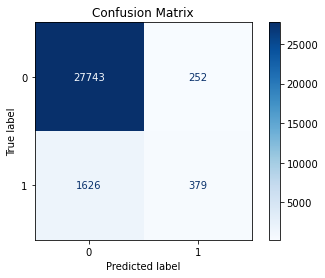

In [32]:
from sklearn.metrics import roc_auc_score, precision_score, recall_score, confusion_matrix,ConfusionMatrixDisplay
import matplotlib.pyplot as plt

prob = best_model.predict_proba(X_val)[:, 1]
pred = (prob >= 0.5).astype(int)

print("AUC:", roc_auc_score(y_val, prob))
print("Precision:", precision_score(y_val, pred))
print("Recall:", recall_score(y_val, pred))
print("KS:", compute_ks(y_val, prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, pred))


cm = confusion_matrix(y_val, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")

plt.title("Confusion Matrix")
plt.show()

In [22]:
predict_and_save(
    best_model,
    test,
    test_ids,
    "../outputs/test_probabilities.csv"
)

Predictions saved to: ../outputs/test_probabilities.csv


In [ ]:
########END##############